# NYC Yellow Taxi Trip Data Analysis

**Dataset:** `yellow_tripdata_2025-11.parquet` (NYC TLC Trip Record Data, November 2025)

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, NLTK

---
## Loading the Dataset

We start by loading the parquet file and checking its structure.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
print('Setup done')

Setup done


In [2]:
df = pd.read_parquet('yellow_tripdata_2025-11.parquet')
print(f'Rows: {df.shape[0]:,}  Columns: {df.shape[1]}')

Rows: 4,181,444  Columns: 20


In [3]:
df.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,7,2025-11-01 00:13:25,2025-11-01 00:13:25,1.0,1.68,1.0,N,43,186,1,14.9,0.00,0.5,1.50,0.00,1.0,22.15,2.5,0.00,0.75
1,2,2025-11-01 00:49:07,2025-11-01 01:01:22,1.0,2.28,1.0,N,142,237,1,14.2,1.00,0.5,4.99,0.00,1.0,24.94,2.5,0.00,0.75
2,1,2025-11-01 00:07:19,2025-11-01 00:20:41,0.0,2.70,1.0,N,163,238,1,15.6,4.25,0.5,4.27,0.00,1.0,25.62,2.5,0.00,0.75
3,2,2025-11-01 00:00:00,2025-11-01 01:01:03,3.0,12.87,1.0,N,138,261,1,66.7,6.00,0.5,0.00,6.94,1.0,86.14,2.5,1.75,0.75
4,1,2025-11-01 00:18:50,2025-11-01 00:49:32,0.0,8.40,1.0,N,138,37,2,39.4,7.75,0.5,0.00,0.00,1.0,48.65,0.0,1.75,0.00
5,2,2025-11-01 00:21:11,2025-11-01 00:31:39,1.0,0.85,1.0,N,90,100,2,10.7,1.00,0.5,0.00,0.00,1.0,16.45,2.5,0.00,0.75
6,2,2025-11-01 00:07:31,2025-11-01 00:25:44,1.0,3.01,1.0,N,142,170,1,19.1,1.00,0.5,1.00,0.00,1.0,25.85,2.5,0.00,0.75
7,2,2025-11-01 00:46:52,2025-11-01 01:38:55,3.0,3.82,1.0,N,237,144,1,42.2,1.00,0.5,9.59,0.00,1.0,57.54,2.5,0.00,0.75
8,2,2025-11-01 00:56:59,2025-11-01 01:02:05,1.0,0.89,1.0,N,162,161,2,7.2,1.00,0.5,0.00,0.00,1.0,12.95,2.5,0.00,0.75
9,2,2025-11-01 00:10:43,2025-11-01 00:39:25,3.0,2.28,1.0,N,234,162,1,24.0,1.00,0.5,8.93,0.00,1.0,38.68,2.5,0.00,0.75


In [4]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4181444 entries, 0 to 4181443
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [6]:
# Quick stats on key numeric columns
print(f'Avg fare: ${np.nanmean(df["fare_amount"]):.2f}')
print(f'Median fare: ${np.nanmedian(df["fare_amount"]):.2f}')
print(f'Std fare: ${np.nanstd(df["fare_amount"]):.2f}')
print(f'Avg trip distance: {np.nanmean(df["trip_distance"]):.2f} miles')
print(f'Max tip: ${np.nanmax(df["tip_amount"]):.2f}')
print(f'Total revenue: ${np.nansum(df["total_amount"]):,.2f}')

Avg fare: $17.12
Median fare: $12.80


Std fare: $19.58
Avg trip distance: 6.53 miles
Max tip: $575.00


Total revenue: $107,107,497.38


In [7]:
# Check value counts for categorical fields
print('VendorID distribution:')
print(df['VendorID'].value_counts())
print('\nPayment type distribution:')
print(df['payment_type'].value_counts())

VendorID distribution:
VendorID
2    3295835
1     821333
7      60043
6       4233
Name: count, dtype: int64

Payment type distribution:
payment_type
1    2704695
0    1014740
2     373932
4      67726
3      20351
Name: count, dtype: int64


The dataset has millions of records with 19 columns covering fares, distances, timestamps and location IDs. Looking at the value counts, one vendor handles the bulk of trips and credit card is the dominant payment type.

---
## Data Cleaning and Visualization

Check for missing values, remove invalid records, then visualize the main distributions.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
print('Plotting libs ready')

Plotting libs ready


In [9]:
# Check missing values
nulls = df.isnull().sum()
nulls_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Missing': nulls, 'Pct': nulls_pct})
null_df[null_df['Missing'] > 0]

,Missing,Pct
passenger_count,1014740,24.27
RatecodeID,1014740,24.27
store_and_fwd_flag,1014740,24.27
congestion_surcharge,1014740,24.27
Airport_fee,1014740,24.27


In [10]:
# Clean the data
df_clean = df.copy()

# Drop rows where passenger_count is null or 0
df_clean = df_clean[df_clean['passenger_count'].notna()]
df_clean = df_clean[df_clean['passenger_count'] > 0]

# Remove negative/zero fares and unreasonable values
df_clean = df_clean[df_clean['fare_amount'] > 0]
df_clean = df_clean[df_clean['fare_amount'] < 500]
df_clean = df_clean[df_clean['trip_distance'] > 0]
df_clean = df_clean[df_clean['trip_distance'] < 100]
df_clean = df_clean[df_clean['total_amount'] > 0]

# Remove negative tips
df_clean = df_clean[df_clean['tip_amount'] >= 0]

print(f'Before cleaning: {len(df):,} rows')
print(f'After cleaning: {len(df_clean):,} rows')
print(f'Removed: {len(df) - len(df_clean):,} rows ({(len(df)-len(df_clean))/len(df)*100:.1f}%)')

Before cleaning: 4,181,444 rows
After cleaning: 3,061,480 rows
Removed: 1,119,964 rows (26.8%)


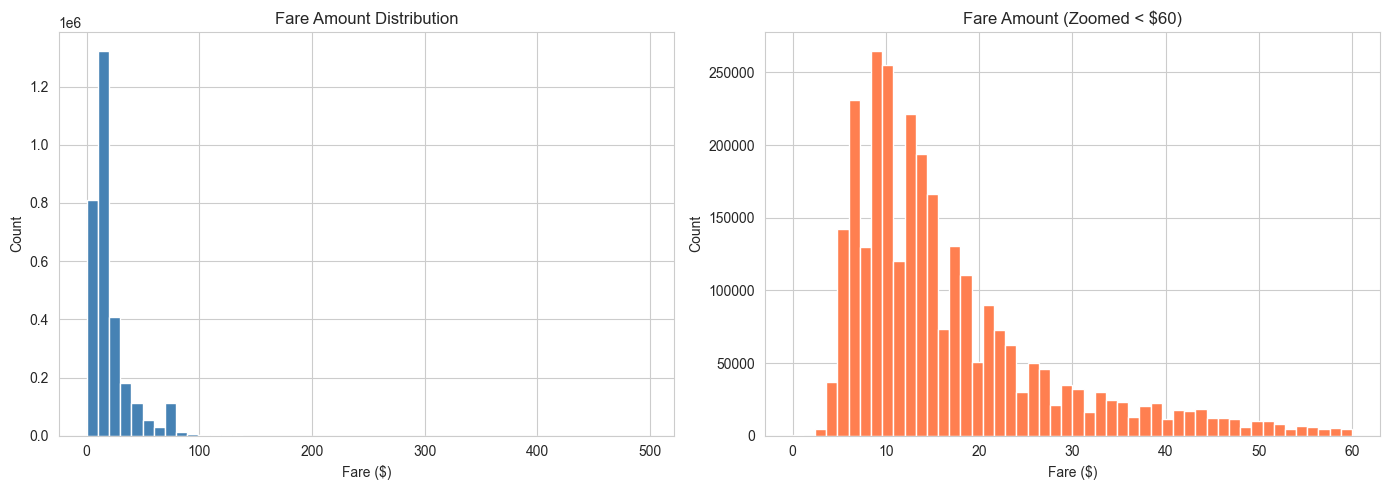

In [11]:
# Fare distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['fare_amount'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Fare Amount Distribution')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Count')

axes[1].hist(df_clean['fare_amount'][df_clean['fare_amount'] < 60], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Fare Amount (Zoomed < $60)')
axes[1].set_xlabel('Fare ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

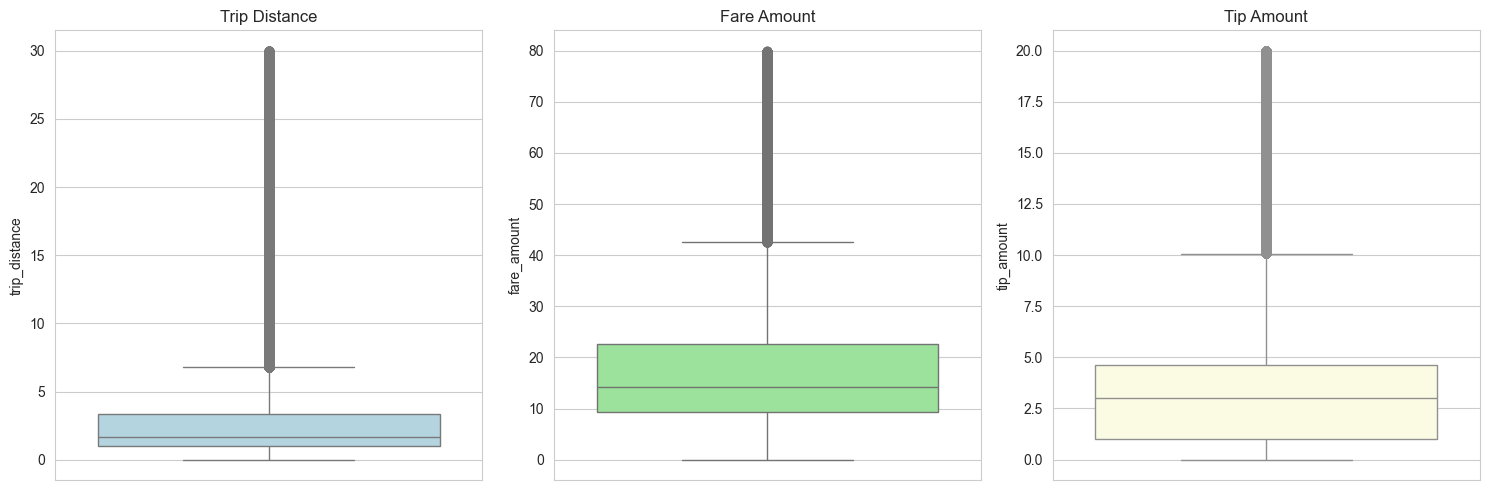

In [12]:
# Box plots for numeric columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df_clean['trip_distance'][df_clean['trip_distance'] < 30], ax=axes[0], color='lightblue')
axes[0].set_title('Trip Distance')

sns.boxplot(y=df_clean['fare_amount'][df_clean['fare_amount'] < 80], ax=axes[1], color='lightgreen')
axes[1].set_title('Fare Amount')

sns.boxplot(y=df_clean['tip_amount'][df_clean['tip_amount'] < 20], ax=axes[2], color='lightyellow')
axes[2].set_title('Tip Amount')

plt.tight_layout()
plt.show()

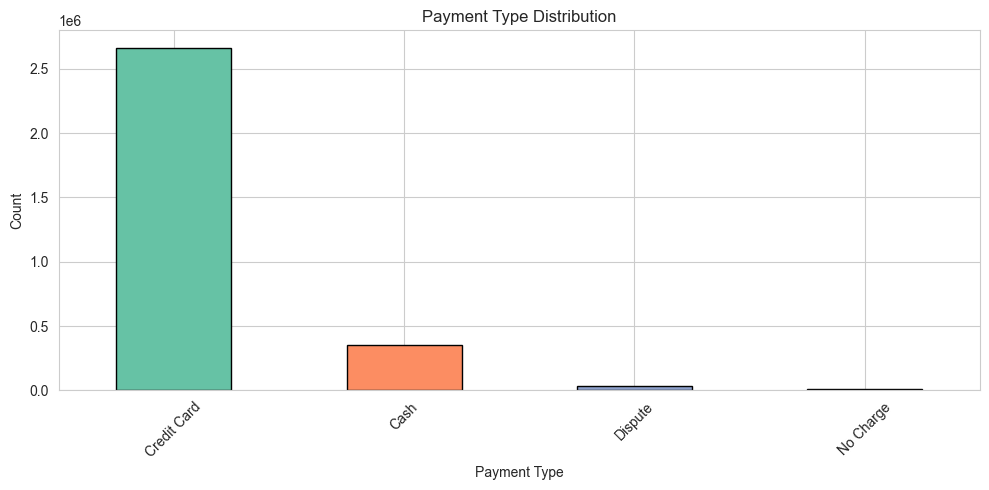

In [13]:
# Payment type bar chart
pay_labels = {0:'Flex Fare', 1:'Credit Card', 2:'Cash', 3:'No Charge', 4:'Dispute', 5:'Unknown', 6:'Voided'}
pay_counts = df_clean['payment_type'].map(pay_labels).value_counts()

plt.figure(figsize=(10, 5))
pay_counts.plot(kind='bar', color=sns.color_palette('Set2', len(pay_counts)), edgecolor='black')
plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

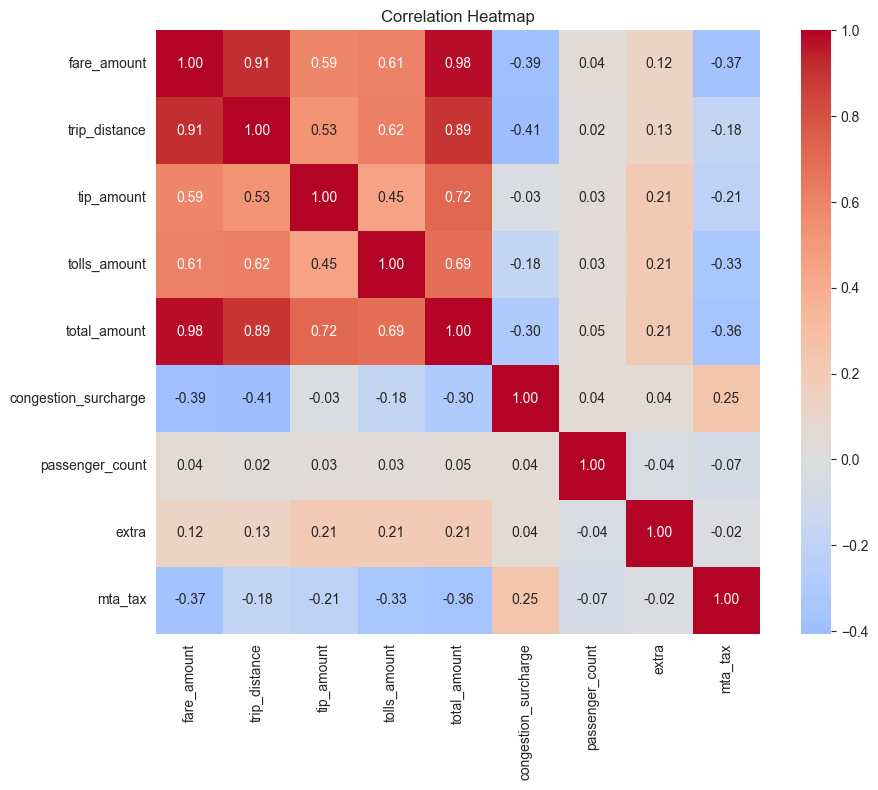

In [14]:
# Correlation heatmap
numeric_cols = ['fare_amount','trip_distance','tip_amount','tolls_amount',
    'total_amount','congestion_surcharge','passenger_count','extra','mta_tax']

plt.figure(figsize=(10, 8))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

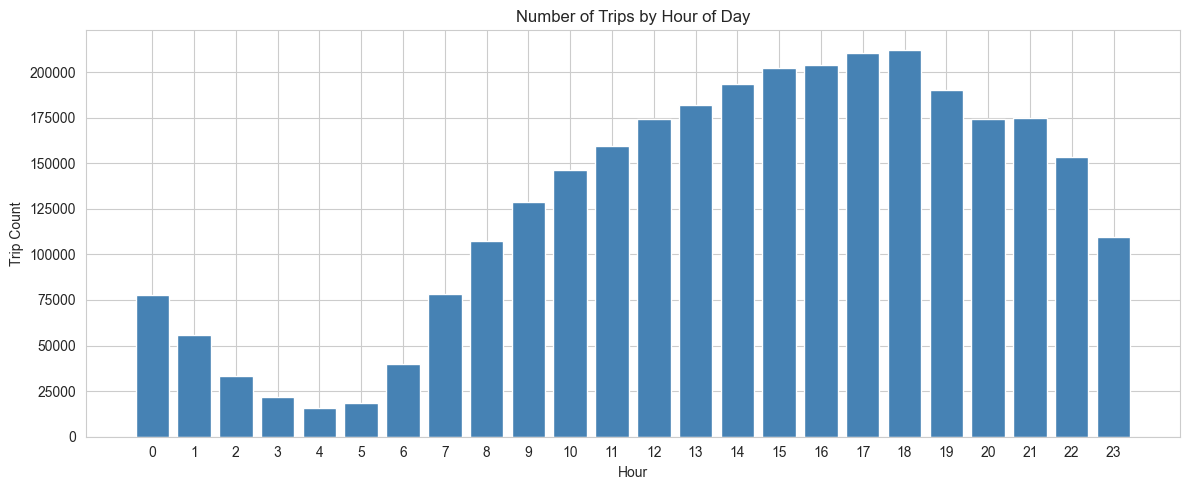

In [15]:
# Trips by hour of day
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour

hourly = df_clean['pickup_hour'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
plt.title('Number of Trips by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Trip Count')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

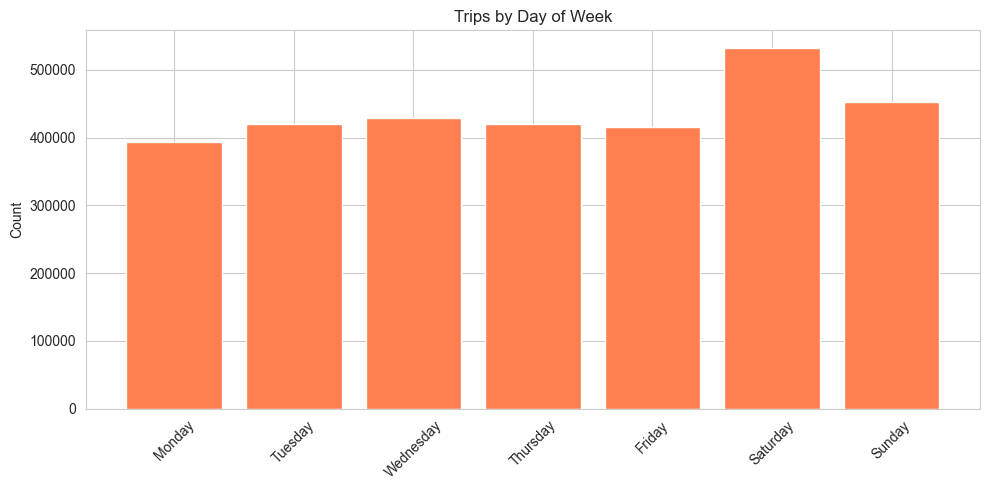

In [16]:
# Trips by day of week
df_clean['pickup_day'] = df_clean['tpep_pickup_datetime'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df_clean['pickup_day'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(daily.index, daily.values, color='coral', edgecolor='white')
plt.title('Trips by Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

After cleaning we removed a small fraction of bad records (negative fares, zero passengers etc). The fare histogram is clearly right-skewed, most trips cost under $20. Credit card dominates as payment method. The heatmap shows trip_distance and fare_amount are highly correlated, and tip_amount also tracks fare well. Peak taxi usage is during evening rush hours, and weekdays see more trips than weekends.

---
## Descriptive Statistics

Compute summary statistics, look at skewness/kurtosis, and compare across groups.

In [17]:
df_clean.describe().round(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_hour
count,3061480.00,3061480,3061480,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00,3061480.00
mean,1.88,2025-11-15 10:40:21.022958,2025-11-15 10:58:30.810329,1.29,3.42,4.54,165.62,165.17,1.15,20.18,1.42,0.49,3.74,0.57,0.96,29.80,2.26,0.15,0.55,14.33
min,1.00,2008-12-31 23:04:21,2008-12-31 23:32:25,1.00,0.01,1.00,1.00,1.00,1.00,0.01,0.00,0.00,0.00,0.00,0.00,1.01,0.00,0.00,0.00,0.00
25%,2.00,2025-11-08 00:56:39,2025-11-08 01:10:52.750000,1.00,1.00,1.00,132.00,114.00,1.00,9.30,0.00,0.50,1.11,0.00,1.00,16.85,2.50,0.00,0.00,11.00
50%,2.00,2025-11-15 07:42:12.500000,2025-11-15 07:55:34.500000,1.00,1.70,1.00,162.00,162.00,1.00,14.20,1.00,0.50,3.00,0.00,1.00,22.26,2.50,0.00,0.75,15.00
75%,2.00,2025-11-22 06:35:54.250000,2025-11-22 06:53:03.750000,1.00,3.33,1.00,234.00,234.00,1.00,23.30,2.50,0.50,4.69,0.00,1.00,32.34,2.50,0.00,0.75,19.00
max,7.00,2025-11-30 23:59:59,2025-12-01 21:41:00,8.00,99.81,99.00,265.00,265.00,4.00,496.50,15.00,4.75,575.00,115.05,1.00,601.72,2.50,6.75,0.75,23.00
std,0.83,NaN,NaN,0.70,4.52,18.08,63.26,69.24,0.45,18.20,1.85,0.06,4.12,2.21,0.18,22.74,0.74,0.51,0.33,5.64


In [18]:
# Skewness and Kurtosis
from scipy import stats

num_cols = ['fare_amount','trip_distance','tip_amount','total_amount','tolls_amount','passenger_count']
sk = df_clean[num_cols].skew().round(3)
kt = df_clean[num_cols].kurtosis().round(3)

pd.DataFrame({'Skewness': sk, 'Kurtosis': kt})

,Skewness,Kurtosis
fare_amount,3.349,25.796
trip_distance,2.894,12.021
tip_amount,5.810,326.038
total_amount,3.136,19.514
tolls_amount,5.512,56.345
passenger_count,3.002,10.448


In [19]:
# Mean, Median, Mode side by side
stats_df = pd.DataFrame({
    'Mean': df_clean[num_cols].mean().round(2),
    'Median': df_clean[num_cols].median().round(2),
    'Mode': df_clean[num_cols].mode().iloc[0].round(2),
    'Std': df_clean[num_cols].std().round(2),
    'Variance': df_clean[num_cols].var().round(2)
})
stats_df

,Mean,Median,Mode,Std,Variance
fare_amount,20.18,14.20,8.6,18.20,331.19
trip_distance,3.42,1.70,0.8,4.52,20.47
tip_amount,3.74,3.00,0.0,4.12,16.96
total_amount,29.80,22.26,17.7,22.74,517.12
tolls_amount,0.57,0.00,0.0,2.21,4.88
passenger_count,1.29,1.00,1.0,0.70,0.48


In [20]:
# Group by VendorID
vendor_stats = df_clean.groupby('VendorID')[['fare_amount','trip_distance','tip_amount','total_amount']].agg(['mean','median','std']).round(2)
vendor_stats

fare_amount               trip_distance              tip_amount  \
                mean median    std          mean median   std       mean   
VendorID                                                                   
1              20.55   14.9  16.42          3.87   1.90  4.73       3.08   
2              20.15   14.2  18.74          3.32   1.67  4.48       3.92   
7              16.93   12.8  14.32          2.66   1.55  3.54       3.70   

                      total_amount                
         median   std         mean median    std  
VendorID                                          
1          2.65  3.79        28.80  22.70  19.37  
2          3.05  4.19        30.16  22.26  23.67  
7          3.08  4.01        26.50  20.95  18.95

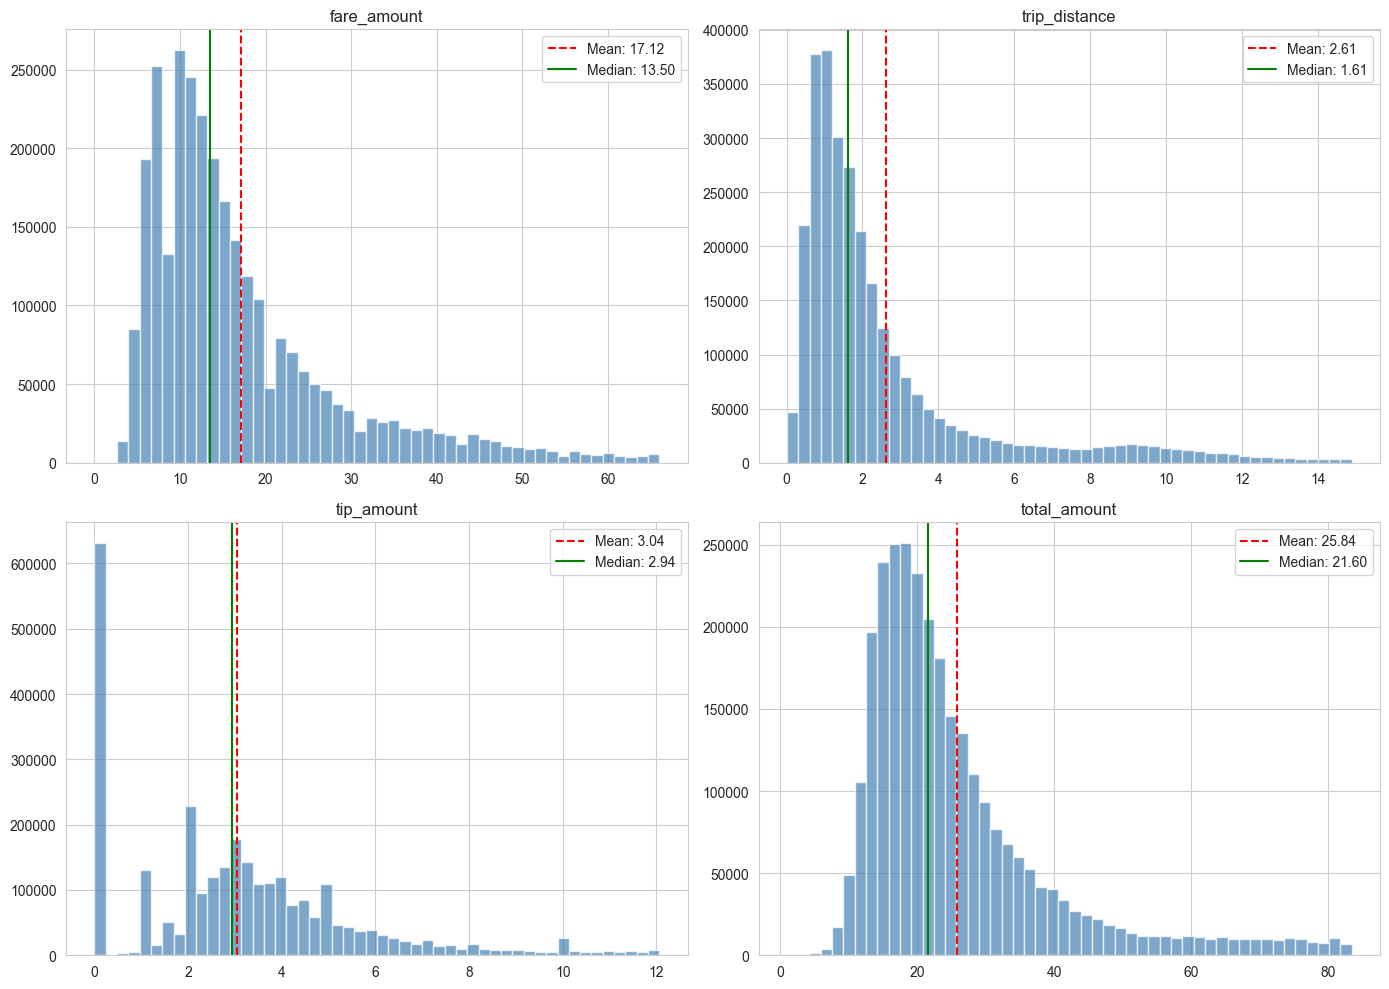

In [21]:
# Distribution plots with mean/median markers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, ['fare_amount','trip_distance','tip_amount','total_amount']):
    data = df_clean[col][df_clean[col] < df_clean[col].quantile(0.95)]
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle='-', label=f'Median: {data.median():.2f}')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

In [22]:
# Percentile analysis for fare_amount
percentiles = [5, 10, 25, 50, 75, 90, 95, 99]
fare_pcts = np.percentile(df_clean['fare_amount'], percentiles)
pct_df = pd.DataFrame({'Percentile': percentiles, 'Fare ($)': fare_pcts.round(2)})
print('Fare Amount Percentiles:')
pct_df

Fare Amount Percentiles:


,Percentile,Fare ($)
0,5,5.8
1,10,7.2
2,25,9.3
3,50,14.2
4,75,23.3
5,90,42.2
6,95,66.0
7,99,82.8


All fare-related columns show positive skewness and high kurtosis which is common for financial data. The mean is above the median in every case, confirming the right skew (pulled up by expensive trips). Both vendors show similar per-trip averages. The percentile table gives a clear picture of fare spread.

---
## Feature Scaling, Encoding and Selection

Normalize the numeric features with different scalers and encode categorical variables for ML.

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold

# Prepare numeric feature matrix
features = ['trip_distance','fare_amount','tip_amount','tolls_amount','extra',
    'mta_tax','congestion_surcharge','total_amount','passenger_count']

# Take a sample for efficiency
df_sample = df_clean[features + ['VendorID','RatecodeID','payment_type']].dropna().sample(50000, random_state=42)
print(f'Sample size: {len(df_sample):,}')

Sample size: 50,000


In [24]:
# StandardScaler
scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(df_sample[features]), columns=features)
print('StandardScaler - Mean and Std after scaling:')
print(X_std.describe().loc[['mean','std']].round(4))

StandardScaler - Mean and Std after scaling:
      trip_distance  fare_amount  tip_amount  tolls_amount  extra  mta_tax  \
mean           -0.0          0.0         0.0          -0.0   -0.0      0.0   
std             1.0          1.0         1.0           1.0    1.0      1.0   

      congestion_surcharge  total_amount  passenger_count  
mean                   0.0           0.0              0.0  
std                    1.0           1.0              1.0  


MinMaxScaler - Min and Max after scaling:
     trip_distance  fare_amount  tip_amount  tolls_amount  extra  mta_tax  \
min            0.0          0.0         0.0           0.0    0.0      0.0   
max            1.0          1.0         1.0           1.0    1.0      1.0   

     congestion_surcharge  total_amount  passenger_count  
min                   0.0           0.0              0.0  
max                   1.0           1.0              1.0  


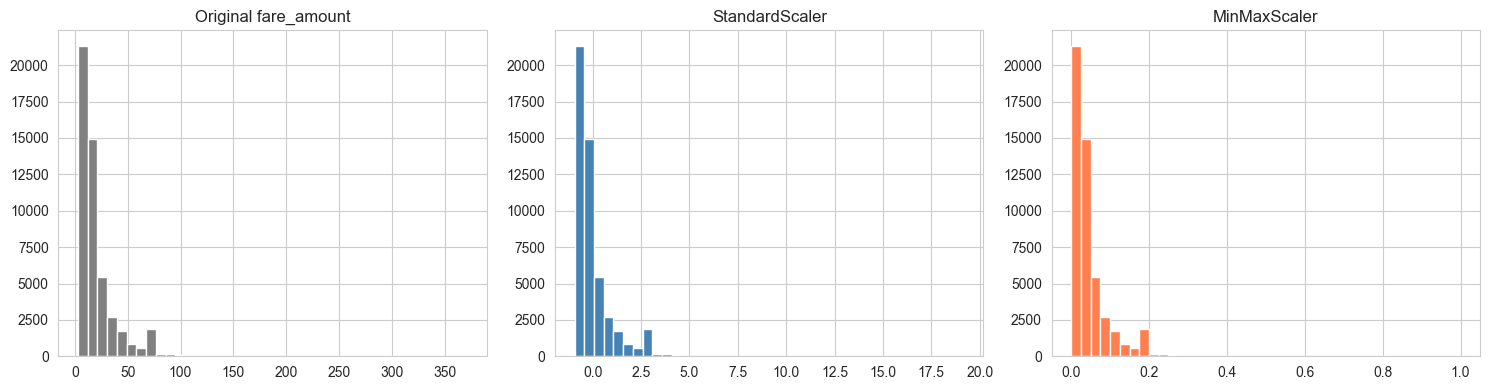

In [25]:
# MinMaxScaler
scaler_mm = MinMaxScaler()
X_mm = pd.DataFrame(scaler_mm.fit_transform(df_sample[features]), columns=features)
print('MinMaxScaler - Min and Max after scaling:')
print(X_mm.describe().loc[['min','max']].round(4))

# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df_sample['fare_amount'], bins=40, color='gray', edgecolor='white')
axes[0].set_title('Original fare_amount')
axes[1].hist(X_std['fare_amount'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('StandardScaler')
axes[2].hist(X_mm['fare_amount'], bins=40, color='coral', edgecolor='white')
axes[2].set_title('MinMaxScaler')
plt.tight_layout()
plt.show()

In [26]:
# Label Encoding for categorical variables
le_vendor = LabelEncoder()
le_rate = LabelEncoder()
le_pay = LabelEncoder()

df_sample['VendorID_enc'] = le_vendor.fit_transform(df_sample['VendorID'])
df_sample['RatecodeID_enc'] = le_rate.fit_transform(df_sample['RatecodeID'].fillna(99).astype(int))
df_sample['payment_type_enc'] = le_pay.fit_transform(df_sample['payment_type'].fillna(0).astype(int))

# One-hot encoding for payment_type
pay_dummies = pd.get_dummies(df_sample['payment_type'].astype(int), prefix='pay')
print('One-hot encoded payment columns:')
pay_dummies.head()

One-hot encoded payment columns:


,pay_1,pay_2,pay_3,pay_4
1798376,True,False,False,False
2380418,True,False,False,False
581231,False,True,False,False
1686503,True,False,False,False
159975,False,True,False,False


Feature correlation with total_amount:
total_amount            1.000
fare_amount             0.976
trip_distance           0.900
tip_amount              0.736
tolls_amount            0.696
mta_tax                 0.376
congestion_surcharge    0.305
extra                   0.208
passenger_count         0.047
dtype: float64


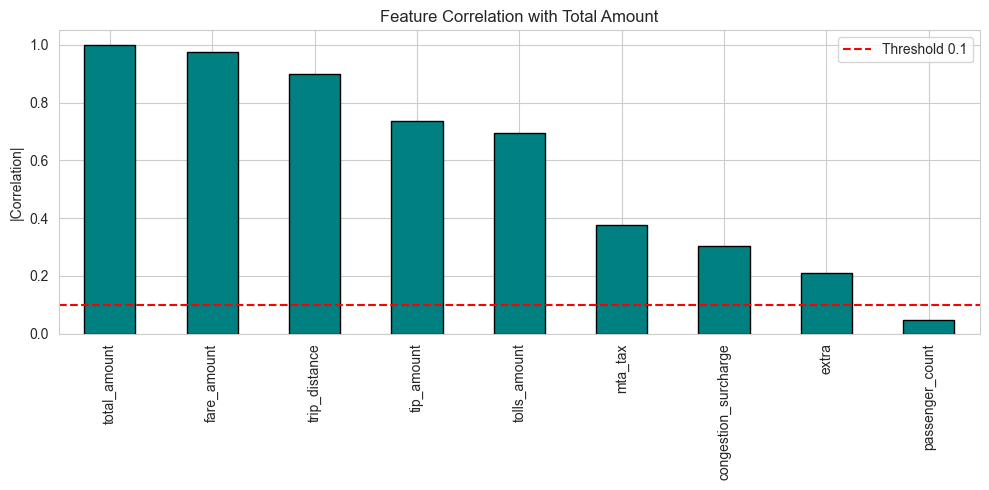

In [27]:
# Correlation-based feature selection
corr_with_total = df_sample[features].corrwith(df_sample['total_amount']).abs().sort_values(ascending=False)
print('Feature correlation with total_amount:')
print(corr_with_total.round(3))

plt.figure(figsize=(10, 5))
corr_with_total.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Feature Correlation with Total Amount')
plt.ylabel('|Correlation|')
plt.axhline(y=0.1, color='red', linestyle='--', label='Threshold 0.1')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Variance Threshold
selector = VarianceThreshold(threshold=0.1)
X_var = selector.fit_transform(X_std)
selected = [features[i] for i in range(len(features)) if selector.get_support()[i]]
removed = [features[i] for i in range(len(features)) if not selector.get_support()[i]]
print(f'Features kept ({len(selected)}): {selected}')
print(f'Features removed ({len(removed)}): {removed}')

Features kept (9): ['trip_distance', 'fare_amount', 'tip_amount', 'tolls_amount', 'extra', 'mta_tax', 'congestion_surcharge', 'total_amount', 'passenger_count']


Features removed (0): []


StandardScaler centers data to mean=0, std=1 while MinMaxScaler squeezes everything into [0,1]. The bar chart shows which features correlate most with total_amount. fare_amount naturally has the highest correlation since it is a component of total. Variance threshold keeps most features since the taxi data has enough spread.

---
## Classification: Predicting High Tips

Create a binary target (is the tip above the median?) and train several classifiers.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

In [30]:
# Prepare classification data: predict high tip (above median)
clf_features = ['trip_distance','fare_amount','passenger_count','extra',
    'mta_tax','tolls_amount','congestion_surcharge']

df_clf = df_clean[clf_features + ['tip_amount']].dropna().sample(50000, random_state=42)
median_tip = df_clf['tip_amount'].median()
df_clf['high_tip'] = (df_clf['tip_amount'] > median_tip).astype(int)

X = df_clf[clf_features]
y = df_clf['high_tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Target balance: {y.value_counts().to_dict()}')
print(f'Median tip threshold: ${median_tip:.2f}')

Train: 40000, Test: 10000
Target balance: {0: 25483, 1: 24517}
Median tip threshold: $3.00


In [31]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Logistic Regression:')
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.67      0.78      0.72      5157
           1       0.71      0.60      0.65      4843

    accuracy                           0.69     10000
   macro avg       0.69      0.69      0.68     10000
weighted avg       0.69      0.69      0.69     10000



In [32]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Decision Tree:')
print(classification_report(y_test, y_pred_dt))

Decision Tree:
              precision    recall  f1-score   support

           0       0.86      0.59      0.70      5157
           1       0.67      0.90      0.77      4843

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.73     10000
weighted avg       0.77      0.74      0.73     10000



In [33]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest:')
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.86      0.60      0.70      5157
           1       0.68      0.89      0.77      4843

    accuracy                           0.74     10000
   macro avg       0.77      0.75      0.74     10000
weighted avg       0.77      0.74      0.74     10000



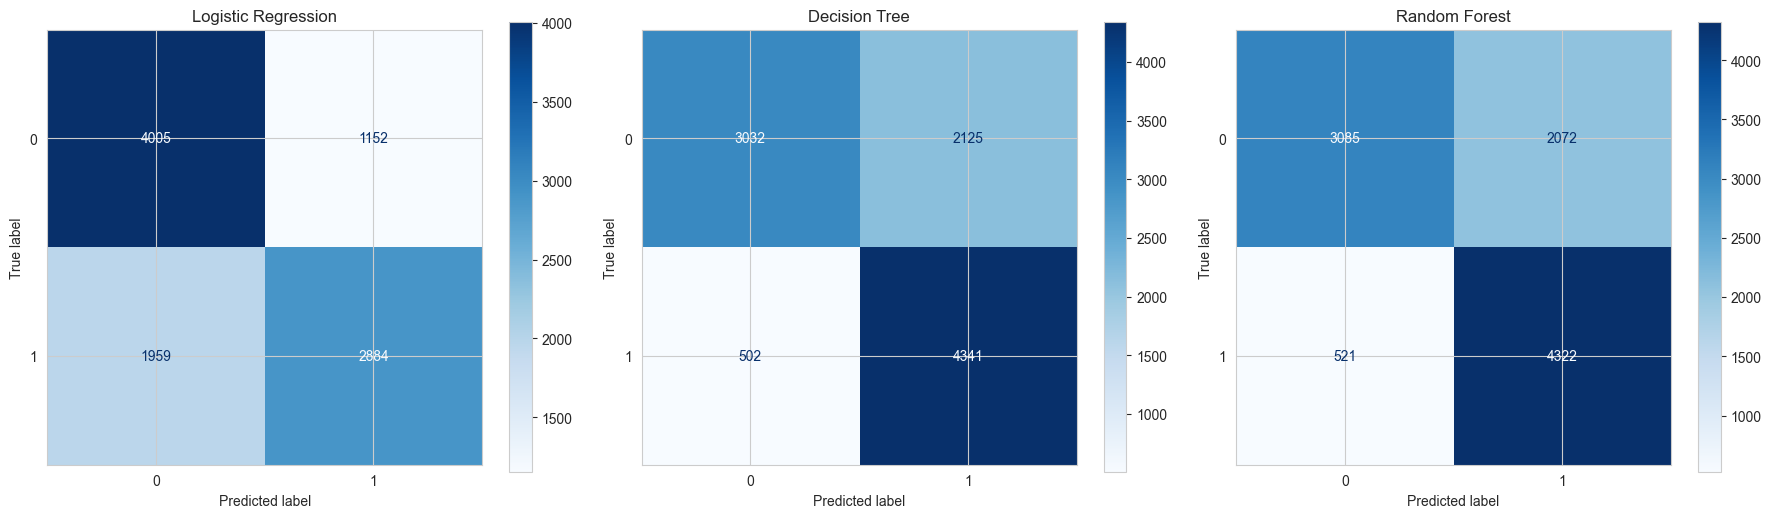

In [34]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in zip(axes, [y_pred_lr, y_pred_dt, y_pred_rf],
    ['Logistic Regression', 'Decision Tree', 'Random Forest']):
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=ax, cmap='Blues')
    ax.set_title(title)
plt.tight_layout()
plt.show()

In [35]:
# Comparison table
models = {'Logistic Regression': y_pred_lr, 'Decision Tree': y_pred_dt, 'Random Forest': y_pred_rf}
results = []
for name, preds in models.items():
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_test, preds, average='weighted'), 4),
        'F1': round(f1_score(y_test, preds, average='weighted'), 4)
    })
pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.6889,0.6924,0.6889,0.6860
1,Decision Tree,0.7373,0.7676,0.7373,0.7316
2,Random Forest,0.7407,0.7686,0.7407,0.7356


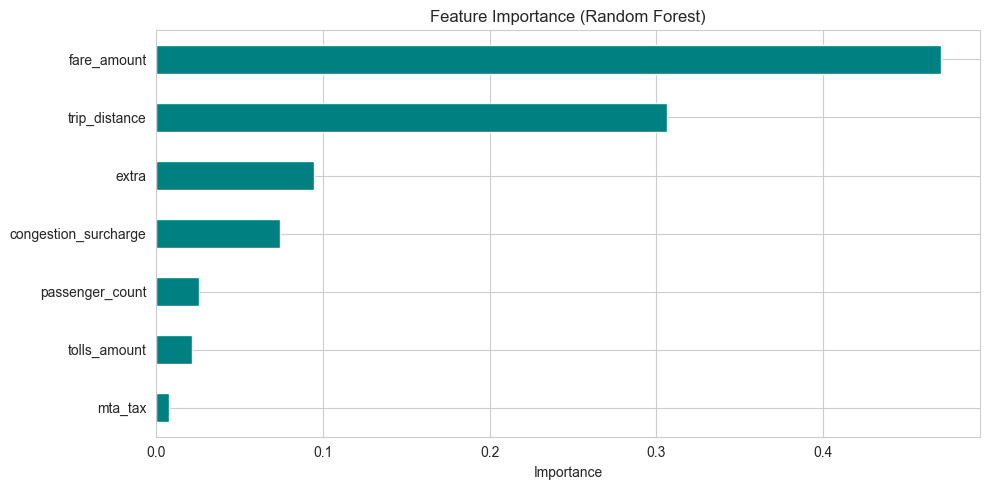

In [36]:
# Feature importance from Random Forest
importance = pd.Series(rf.feature_importances_, index=clf_features).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importance.plot(kind='barh', color='teal')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

The comparison table above shows Random Forest gives the best numbers across all metrics. fare_amount and trip_distance are the top features for predicting tips, which makes sense since longer and pricier trips tend to get larger tips.

---
## Regression: Predicting Total Amount

Train regression models to predict total_amount from trip features and compare their performance.

In [37]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [38]:
# Prepare regression data
reg_features = ['trip_distance','fare_amount','tip_amount','passenger_count',
    'extra','mta_tax','tolls_amount','congestion_surcharge']

df_reg = df_clean[reg_features + ['total_amount']].dropna().sample(50000, random_state=42)
X_r = df_reg[reg_features]
y_r = df_reg['total_amount']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)
print(f'Train: {len(X_train_r)}, Test: {len(X_test_r)}')

Train: 40000, Test: 10000


In [39]:
# Linear Regression
lr_reg = LinearRegression()
lr_reg.fit(X_train_r, y_train_r)
y_pred_lr_r = lr_reg.predict(X_test_r)
print('Linear Regression:')
print(f'  R2: {r2_score(y_test_r, y_pred_lr_r):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_lr_r)):.4f}')
print(f'  MAE: {mean_absolute_error(y_test_r, y_pred_lr_r):.4f}')

Linear Regression:
  R2: 0.9976
  RMSE: 1.1331
  MAE: 0.8096


In [40]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_r, y_train_r)
y_pred_ridge = ridge.predict(X_test_r)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_r, y_train_r)
y_pred_lasso = lasso.predict(X_test_r)

print('Ridge R2:', round(r2_score(y_test_r, y_pred_ridge), 4))
print('Lasso R2:', round(r2_score(y_test_r, y_pred_lasso), 4))

Ridge R2: 0.9976
Lasso R2: 0.9975


In [41]:
# Decision Tree Regressor
dtr = DecisionTreeRegressor(max_depth=15, random_state=42)
dtr.fit(X_train_r, y_train_r)
y_pred_dtr = dtr.predict(X_test_r)

# Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rfr.fit(X_train_r, y_train_r)
y_pred_rfr = rfr.predict(X_test_r)

print('Decision Tree R2:', round(r2_score(y_test_r, y_pred_dtr), 4))
print('Random Forest R2:', round(r2_score(y_test_r, y_pred_rfr), 4))

Decision Tree R2: 0.9962
Random Forest R2: 0.9978


In [42]:
# Comparison table
reg_results = []
for name, preds in [('Linear', y_pred_lr_r), ('Ridge', y_pred_ridge),
    ('Lasso', y_pred_lasso), ('Decision Tree', y_pred_dtr), ('Random Forest', y_pred_rfr)]:
    reg_results.append({
        'Model': name,
        'R2': round(r2_score(y_test_r, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_r, preds)), 4),
        'MAE': round(mean_absolute_error(y_test_r, preds), 4)
    })
pd.DataFrame(reg_results)

,Model,R2,RMSE,MAE
0,Linear,0.9976,1.1331,0.8096
1,Ridge,0.9976,1.1331,0.8096
2,Lasso,0.9975,1.1517,0.8271
3,Decision Tree,0.9962,1.4032,0.4244
4,Random Forest,0.9978,1.0654,0.3547


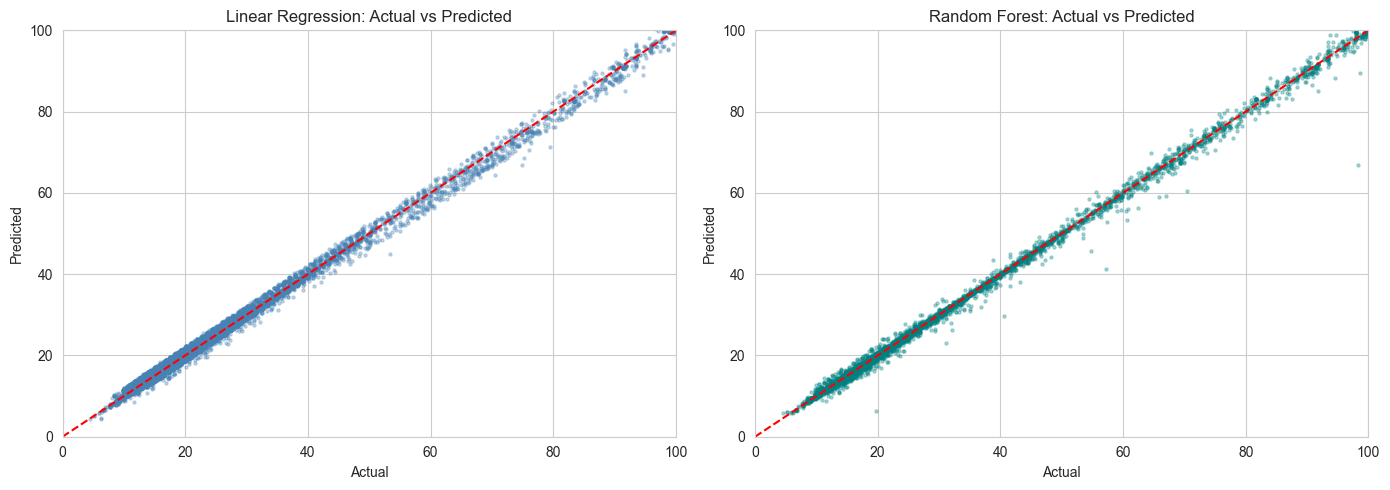

In [43]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_lr_r, alpha=0.3, s=5, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

axes[1].scatter(y_test_r, y_pred_rfr, alpha=0.3, s=5, color='teal')
axes[1].plot([0, 100], [0, 100], 'r--')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

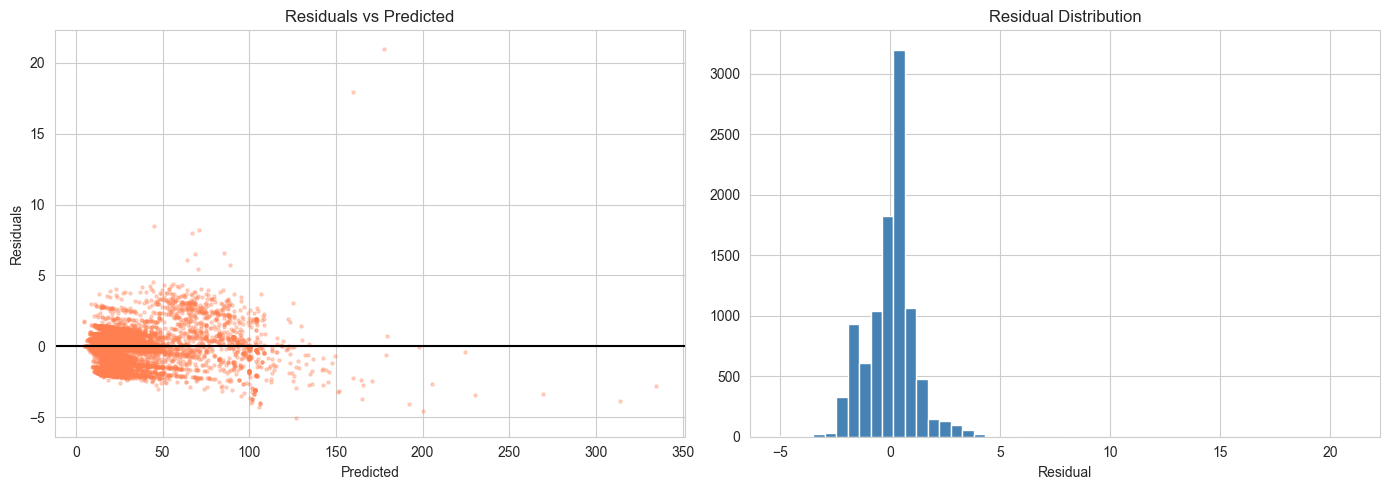

In [44]:
# Residual analysis for Linear Regression
residuals = y_test_r - y_pred_lr_r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_lr_r, residuals, alpha=0.3, s=5, color='coral')
axes[0].axhline(y=0, color='black', linestyle='-')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

All models get very high R2 here because total_amount is basically the sum of the other fare components (fare + tip + tolls + surcharges), so the relationship is close to linear. Linear, Ridge and Lasso give nearly identical results. The residual plot is centered around 0 which is good.

---
## Cross-Validation and Hyperparameter Tuning

Evaluate models with k-fold cross-validation and search for better hyperparameters.

In [45]:
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, learning_curve

# Cross-validation on classification models
cv_results = {}
for name, model in [('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
                    ('Decision Tree', DecisionTreeClassifier(max_depth=10, random_state=42)),
                    ('Random Forest', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))]:
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name}: mean={scores.mean():.4f} std={scores.std():.4f}')


Logistic Regression: mean=0.6843 std=0.0045
Decision Tree: mean=0.7388 std=0.0051


Random Forest: mean=0.6905 std=0.0029


In [46]:
# GridSearchCV on Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='accuracy', verbose=0, n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV accuracy:', round(grid_search.best_score_, 4))
print('Test accuracy:', round(grid_search.score(X_test, y_test), 4))

Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.7443
Test accuracy: 0.7428


In [47]:
# RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(5, 25),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5)
}

random_search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist, n_iter=15, cv=3, scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print('Best params:', random_search.best_params_)
print('Best CV accuracy:', round(random_search.best_score_, 4))
print('Test accuracy:', round(random_search.score(X_test, y_test), 4))

Best params: {'max_depth': 11, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 64}
Best CV accuracy: 0.744
Test accuracy: 0.7438


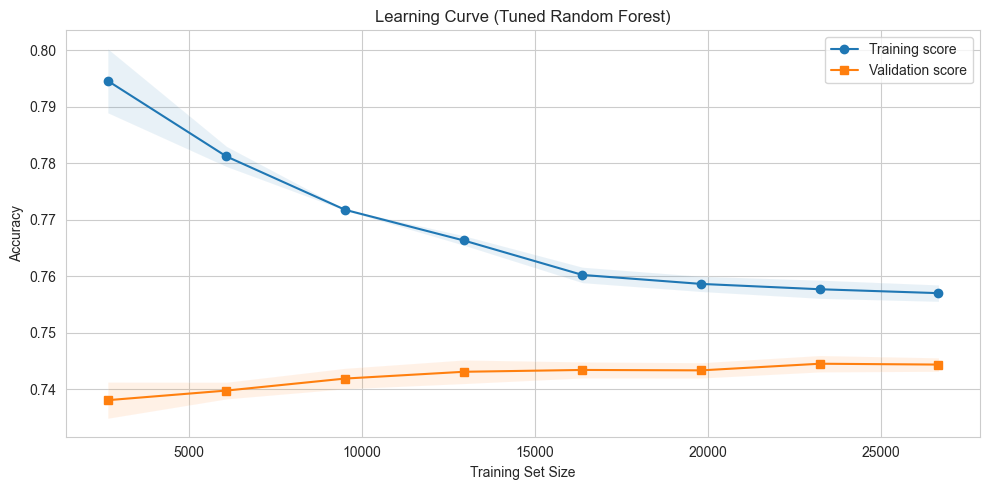

In [48]:
# Learning curve for best model
train_sizes, train_scores, val_scores = learning_curve(
    grid_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=3, scoring='accuracy', n_jobs=-1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), 's-', label='Validation score')
plt.fill_between(train_sizes, train_scores.mean(axis=1)-train_scores.std(axis=1),
    train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1),
    val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.1)
plt.title('Learning Curve (Tuned Random Forest)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

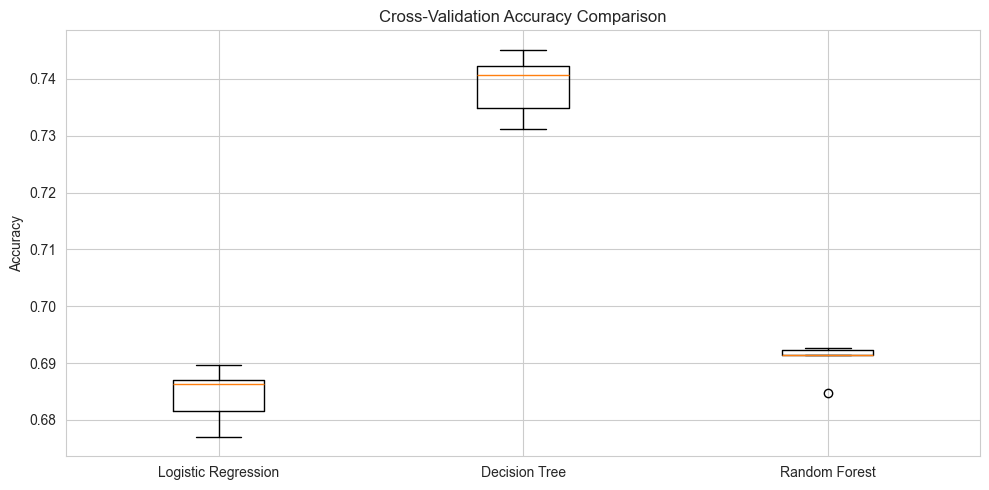

In [49]:
# CV score comparison plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_title('Cross-Validation Accuracy Comparison')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

Cross-validation confirms the Random Forest is the most reliable classifier with the smallest variance across folds. GridSearchCV and RandomizedSearchCV both land on similar optimal parameters. The learning curve shows training and validation scores converging, so the model is not overfitting badly.

---
## Grouping Trips with K-Means Clustering

Use K-Means to segment trips into groups based on distance, fare, tip and passenger count.

In [50]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Prepare clustering features
clust_features = ['trip_distance','fare_amount','tip_amount','passenger_count','tolls_amount']
df_clust = df_clean[clust_features].dropna().sample(20000, random_state=42)

scaler_c = StandardScaler()
X_clust = scaler_c.fit_transform(df_clust)
print(f'Clustering on {len(df_clust)} samples, {len(clust_features)} features')

Clustering on 20000 samples, 5 features


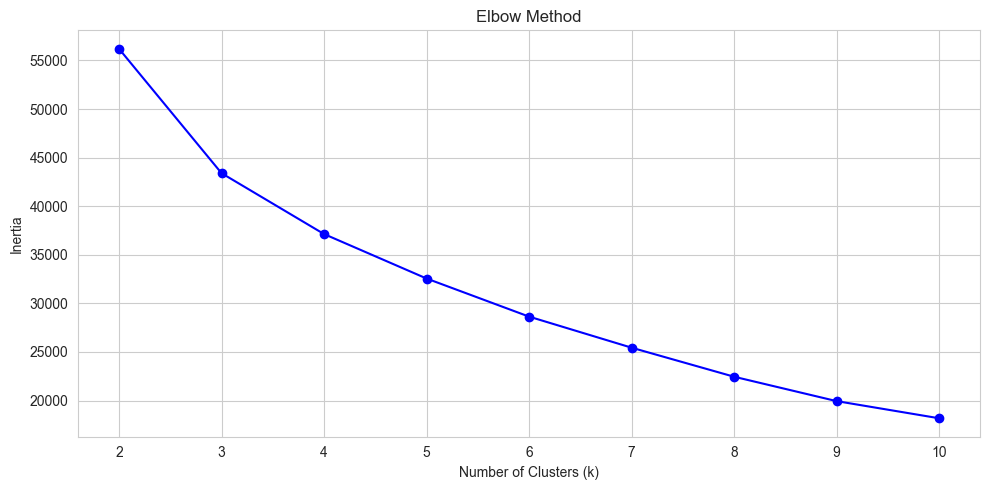

In [51]:
# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

k=2: silhouette=0.6823


k=3: silhouette=0.5014


k=4: silhouette=0.5131


k=5: silhouette=0.5201


k=6: silhouette=0.4704


k=7: silhouette=0.4733


k=8: silhouette=0.4749


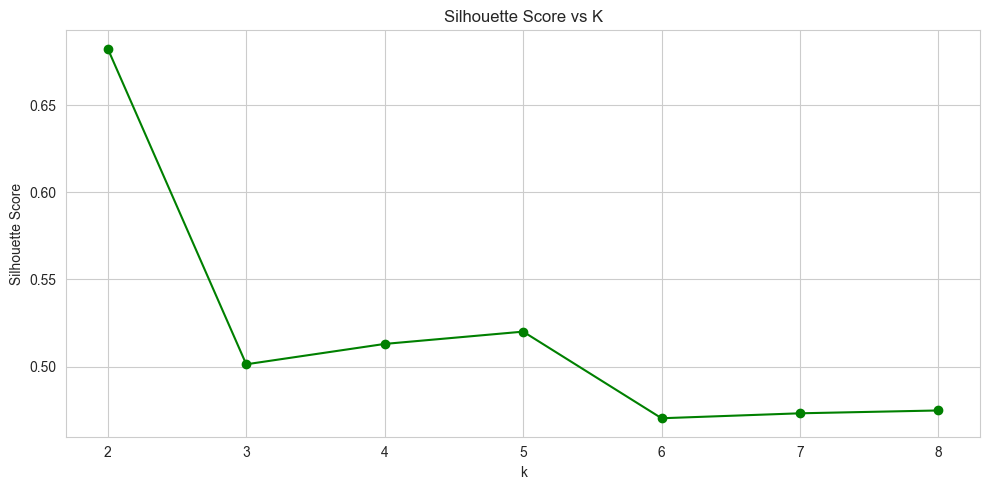

In [52]:
# Silhouette scores
sil_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    score = silhouette_score(X_clust, labels, sample_size=5000)
    sil_scores.append(score)
    print(f'k={k}: silhouette={score:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(range(2, 9), sil_scores, 'go-')
plt.title('Silhouette Score vs K')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
# KMeans with k=4 (from the elbow/silhouette above)
optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = km_final.fit_predict(X_clust)
df_clust['cluster'] = clusters

print('Cluster sizes:')
print(df_clust['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0     3373
1     1493
2    13255
3     1879
Name: count, dtype: int64


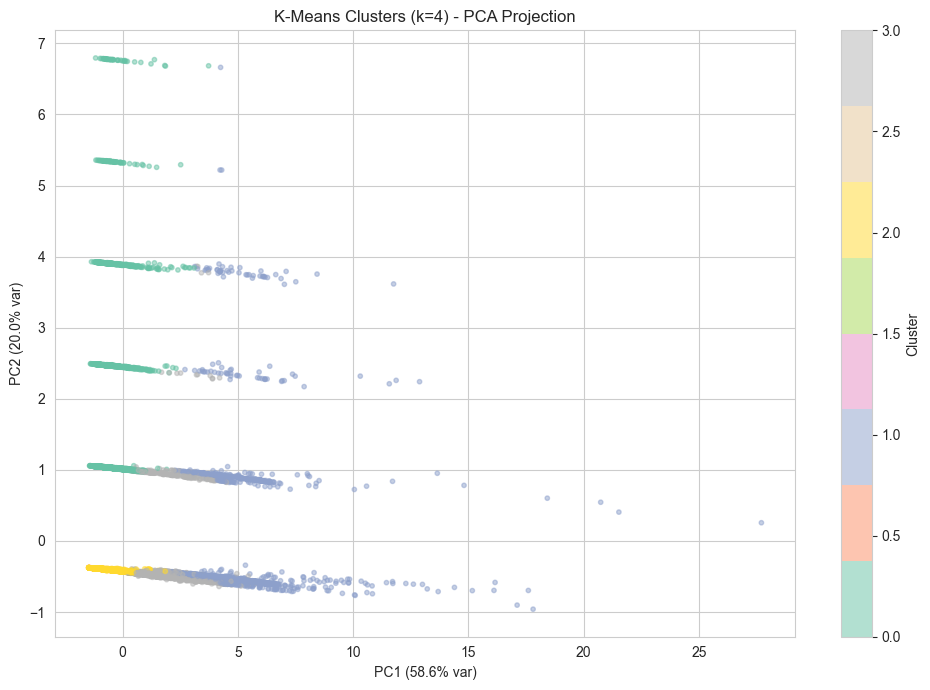

In [54]:
# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set2', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clusters (k={optimal_k}) - PCA Projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.show()

In [55]:
# Cluster profiles
print('Cluster means (original scale):')
df_clust.groupby('cluster')[clust_features].mean().round(2)

Cluster means (original scale):


,trip_distance,fare_amount,tip_amount,passenger_count,tolls_amount
cluster,,,,,
0,1.89,14.69,2.89,2.51,0.03
1,14.65,63.31,12.40,1.37,7.01
2,1.70,13.33,2.79,1.00,0.01
3,9.36,43.97,5.19,1.12,0.47


The elbow plot bends around k=4 and the silhouette scores support that. Looking at the cluster means, the groups roughly separate out short cheap trips, medium-distance rides, longer expensive rides, and trips with tolls (likely airport). Silhouette scores are moderate which is normal for messy real-world data.

---
## Density-Based Clustering with DBSCAN

DBSCAN finds clusters based on point density and can identify noise/outlier points automatically.

In [56]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Use a smaller sample (DBSCAN is expensive)
X_db = X_clust[:5000]  # already scaled from above

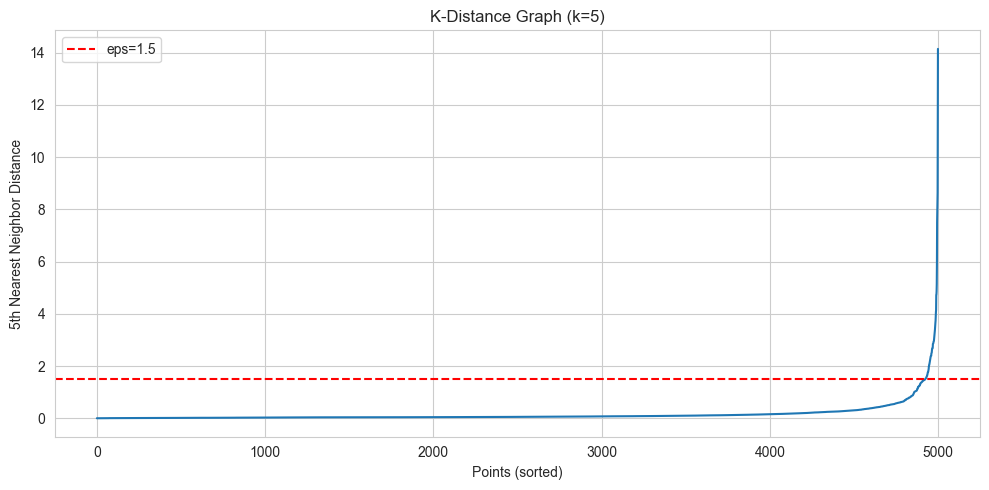

In [57]:
# K-distance graph to find a good eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_db)
distances, _ = nn.kneighbors(X_db)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Graph (k=5)')
plt.xlabel('Points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=1.5, color='r', linestyle='--', label='eps=1.5')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [58]:
# DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=10)
db_labels = dbscan.fit_predict(X_db)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print(f'DBSCAN found {n_clusters} clusters')
print(f'Noise points: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')
print(f'Cluster sizes: {pd.Series(db_labels).value_counts().to_dict()}')

DBSCAN found 1 clusters
Noise points: 63 (1.3%)
Cluster sizes: {0: 4937, -1: 63}


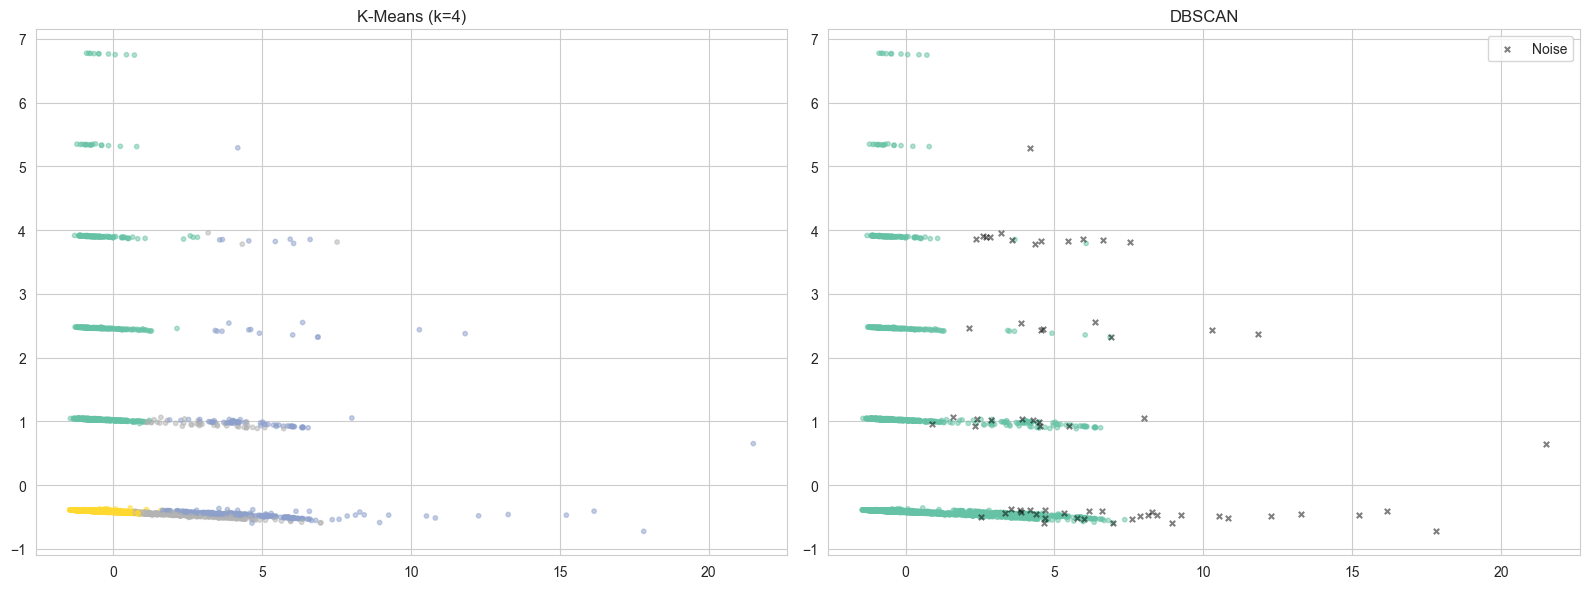

In [59]:
# Visualize DBSCAN vs KMeans
pca_db = PCA(n_components=2)
X_pca_db = pca_db.fit_transform(X_db)

km_compare = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km_compare.fit_predict(X_db)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(X_pca_db[:, 0], X_pca_db[:, 1], c=km_labels, cmap='Set2', alpha=0.5, s=10)
axes[0].set_title('K-Means (k=4)')

colors = db_labels.copy().astype(float)
colors[db_labels == -1] = np.nan
axes[1].scatter(X_pca_db[:, 0], X_pca_db[:, 1], c=colors, cmap='Set2', alpha=0.5, s=10)
noise_mask = db_labels == -1
axes[1].scatter(X_pca_db[noise_mask, 0], X_pca_db[noise_mask, 1],
    c='black', marker='x', s=15, alpha=0.5, label='Noise')
axes[1].set_title('DBSCAN')
axes[1].legend()

plt.tight_layout()
plt.show()

In [60]:
# Try different eps values
for eps in [0.8, 1.0, 1.5, 2.0, 2.5]:
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_db)
    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    n_n = list(labels).count(-1)
    print(f'eps={eps}: {n_c} clusters, {n_n} noise points ({n_n/len(labels)*100:.1f}%)')

eps=0.8: 10 clusters, 173 noise points (3.5%)


eps=1.0: 10 clusters, 132 noise points (2.6%)


eps=1.5: 1 clusters, 63 noise points (1.3%)


eps=2.0: 1 clusters, 51 noise points (1.0%)


eps=2.5: 1 clusters, 30 noise points (0.6%)


DBSCAN picks up the dense core of normal trips and marks unusual ones (very long, very expensive, etc.) as noise. Smaller eps means stricter density requirements and more noise points. Compared to KMeans, DBSCAN does not force every point into a cluster, so it is better at spotting anomalous trips.

---
## Generative AI Overview

Generative AI covers models that can produce new content like text, images or code. Large Language Models (LLMs) such as GPT, Gemini and LLaMA are built on the Transformer architecture.

### Key Concepts

- **Transformers:** Self-attention mechanism that processes sequences in parallel, enabling training on huge text corpora
- **LLMs:** Neural networks pre-trained on massive text data, then fine-tuned for specific tasks
- **Prompt Engineering:** Writing input prompts carefully to get better outputs from LLMs
- **Few-shot Learning:** Including examples in the prompt to guide the model's response
- **Temperature:** Controls randomness in generation, lower = more deterministic, higher = more creative

In [61]:
# Simple n-gram based text generation to show the core idea
# - predict next token based on previous ones
import random
from collections import defaultdict

# Generate trip descriptions as training corpus
trip_texts = []
for _, row in df_clean.sample(1000, random_state=42).iterrows():
    dist = row['trip_distance']
    fare = row['fare_amount']
    pax = int(row.get('passenger_count', 1)) if pd.notna(row.get('passenger_count')) else 1
    if dist < 2: trip_type = 'short'
    elif dist < 5: trip_type = 'medium'
    else: trip_type = 'long'
    trip_texts.append(f'a {trip_type} trip with {pax} passengers fare {int(fare)} dollars')

# Build bigram model
bigrams = defaultdict(list)
for text in trip_texts:
    words = text.split()
    for i in range(len(words)-1):
        bigrams[words[i]].append(words[i+1])

# Generate text
def generate(start_word, length=10):
    result = [start_word]
    word = start_word
    for _ in range(length):
        if word in bigrams:
            word = random.choice(bigrams[word])
            result.append(word)
        else:
            break
    return ' '.join(result)

random.seed(42)
print('Generated trip descriptions (bigram model):')
for _ in range(5):
    print(f'  > {generate("a", 8)}')

Generated trip descriptions (bigram model):
  > a long trip with 2 passengers fare 55 dollars
  > a medium trip with 1 passengers fare 5 dollars
  > a short trip with 1 passengers fare 20 dollars
  > a short trip with 1 passengers fare 45 dollars
  > a medium trip with 2 passengers fare 17 dollars


### Prompt Engineering Examples

When using an LLM for data analysis, prompt structure matters:

**Zero-shot:** *"Analyze this taxi trip data and identify patterns."*

**Few-shot:** *"Given trip data where distance=2.5mi, fare=$12, tip=$3, this is a standard Manhattan trip. Now analyze: distance=18mi, fare=$52, tip=$0"*

**Chain-of-thought:** *"Step 1: Check the fare vs distance ratio. Step 2: Check if tip is proportional. Step 3: Identify the likely route type..."*

These techniques help LLMs produce more structured and accurate outputs for data tasks.

The bigram model above generates somewhat coherent trip descriptions by learning which words follow which. Real LLMs use transformer attention with billions of parameters for much better text generation. Prompt engineering techniques like few-shot and chain-of-thought can improve the quality of LLM outputs.

---
## Text Preprocessing (NLP)

Apply basic NLP steps: tokenization, stopword removal, stemming and lemmatization on text descriptions generated from the trip data.

In [62]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from collections import Counter
print('NLTK ready')

NLTK ready


In [63]:
# Generate text descriptions from taxi trips
pay_map = {0:'flex', 1:'credit card', 2:'cash', 3:'free', 4:'dispute', 5:'unknown', 6:'voided'}
rate_map = {1:'standard', 2:'JFK', 3:'Newark', 4:'Nassau', 5:'negotiated', 6:'group'}

texts = []
df_nlp = df_clean.sample(2000, random_state=42)
for _, r in df_nlp.iterrows():
    pay = pay_map.get(int(r.get('payment_type', 0)) if pd.notna(r.get('payment_type')) else 0, 'unknown')
    rate = rate_map.get(int(r.get('RatecodeID', 1)) if pd.notna(r.get('RatecodeID')) else 1, 'standard')
    dist = r['trip_distance']
    fare = r['fare_amount']
    pax = int(r['passenger_count']) if pd.notna(r.get('passenger_count')) else 1
    tip = r.get('tip_amount', 0) if pd.notna(r.get('tip_amount')) else 0
    texts.append(f'a {rate} rate taxi trip covering {dist:.1f} miles with {pax} passengers '
                 f'the fare was {fare:.0f} dollars paid by {pay} with a tip of {tip:.0f} dollars')

print(f'Generated {len(texts)} trip descriptions')
print(f'Sample: {texts[0]}')

Generated 2000 trip descriptions
Sample: a standard rate taxi trip covering 1.8 miles with 1 passengers the fare was 16 dollars paid by credit card with a tip of 1 dollars


In [64]:
# Tokenization
sample = texts[0]
tokens = word_tokenize(sample)
print(f'Original: {sample}')
print(f'Tokens ({len(tokens)}): {tokens}')

Original: a standard rate taxi trip covering 1.8 miles with 1 passengers the fare was 16 dollars paid by credit card with a tip of 1 dollars
Tokens (26): ['a', 'standard', 'rate', 'taxi', 'trip', 'covering', '1.8', 'miles', 'with', '1', 'passengers', 'the', 'fare', 'was', '16', 'dollars', 'paid', 'by', 'credit', 'card', 'with', 'a', 'tip', 'of', '1', 'dollars']


In [65]:
# Stopword removal
stop_words = set(stopwords.words('english'))

filtered = [t for t in tokens if t.lower() not in stop_words]
print(f'Before stopword removal: {len(tokens)} tokens')
print(f'After stopword removal: {len(filtered)} tokens')
print(f'Removed: {[t for t in tokens if t.lower() in stop_words]}')

Before stopword removal: 26 tokens
After stopword removal: 18 tokens
Removed: ['a', 'with', 'the', 'was', 'by', 'with', 'a', 'of']


In [66]:
# Stemming vs Lemmatization
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

test_words = ['covering', 'passengers', 'dollars', 'paid', 'miles', 'trips', 'driving', 'negotiated']
print(f'{"Word":<15} {"Stem":<15} {"Lemma":<15}')
print('-' * 45)
for w in test_words:
    print(f'{w:<15} {stemmer.stem(w):<15} {lemmatizer.lemmatize(w):<15}')

Word            Stem            Lemma          
---------------------------------------------


covering        cover           covering       
passengers      passeng         passenger      
dollars         dollar          dollar         
paid            paid            paid           
miles           mile            mile           
trips           trip            trip           
driving         drive           driving        
negotiated      negoti          negotiated     


Top 20 words:


  dollars: 4000
  rate: 2000
  taxi: 2000
  trip: 2000
  covering: 2000
  miles: 2000
  passengers: 2000
  fare: 2000
  paid: 2000
  tip: 2000
  standard: 1918
  credit: 1761
  card: 1761
  cash: 212
  jfk: 54
  dispute: 19
  negotiated: 19
  free: 8
  newark: 6
  nassau: 3


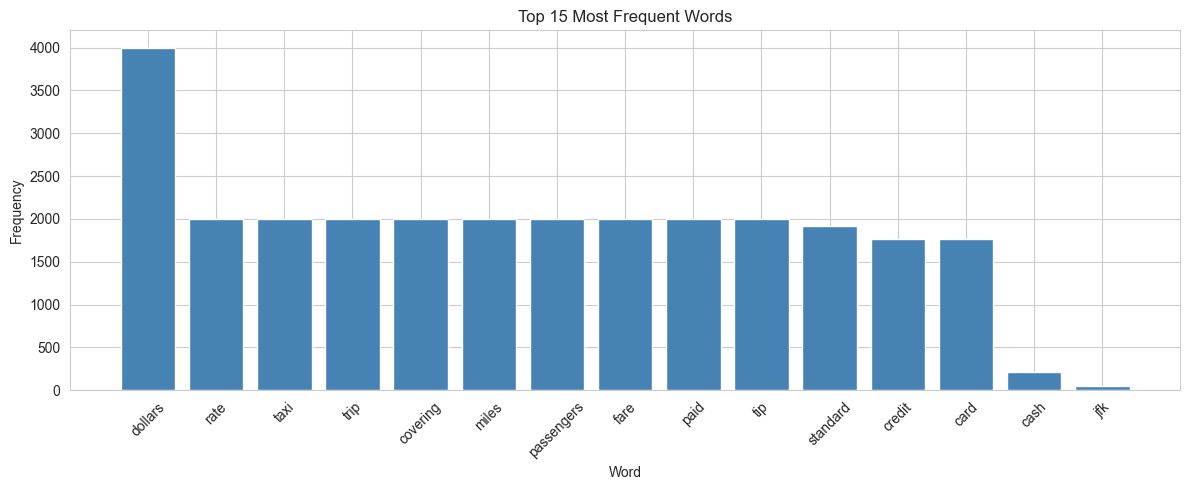

In [67]:
# Word frequency across all trip descriptions
all_tokens = []
for t in texts:
    words = word_tokenize(t.lower())
    words = [w for w in words if w.isalpha() and w not in stop_words]
    all_tokens.extend(words)

freq = Counter(all_tokens)
print('Top 20 words:')
for word, count in freq.most_common(20):
    print(f'  {word}: {count}')

# Bar chart
top_words = freq.most_common(15)
plt.figure(figsize=(12, 5))
plt.bar([w[0] for w in top_words], [w[1] for w in top_words], color='steelblue', edgecolor='white')
plt.title('Top 15 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

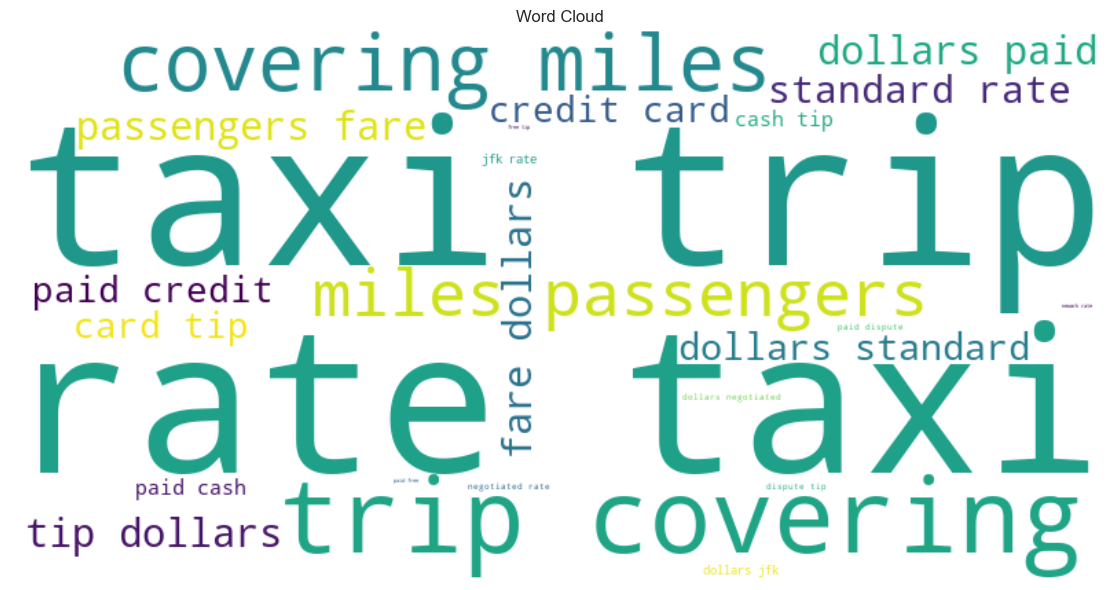

In [68]:
# Word Cloud
try:
    from wordcloud import WordCloud
    wc = WordCloud(width=800, height=400, background_color='white',
        colormap='viridis', max_words=100)
    wc.generate(' '.join(all_tokens))

    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud')
    plt.tight_layout()
    plt.show()
except ImportError:
    print('wordcloud not installed, skipping')

Tokenization splits text into individual words. Stopword removal filters out common words like 'the', 'a', 'with'. Stemming is more aggressive (e.g. passengers becomes passeng) while lemmatization gives proper dictionary forms (passengers becomes passenger). The most frequent words are all taxi related: dollars, trip, fare, miles, paid etc.

---
## Text Vectorization and Similarity

Convert the trip descriptions to numeric vectors using TF-IDF and measure how similar they are.

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [70]:
# Bag of Words
cv = CountVectorizer(max_features=50, stop_words='english')
bow_matrix = cv.fit_transform(texts)

print(f'BoW matrix shape: {bow_matrix.shape}')
print(f'Vocabulary (first 20): {list(cv.vocabulary_.keys())[:20]}')

# Show BoW for first 3 docs
bow_df = pd.DataFrame(bow_matrix[:3].toarray(), columns=cv.get_feature_names_out())
print('\nBoW vectors for first 3 trip descriptions:')
bow_df

BoW matrix shape: (2000, 50)
Vocabulary (first 20): ['standard', 'rate', 'taxi', 'trip', 'covering', 'miles', 'passengers', 'fare', '16', 'dollars', 'paid', 'credit', 'card', 'tip', '11', 'cash', '13', '27', '10', '39']

BoW vectors for first 3 trip descriptions:


,10,11,12,13,14,15,16,17,18,19,...,jfk,miles,negotiated,paid,passengers,rate,standard,taxi,tip,trip
0,0,0,0,0,0,0,1,0,0,0,...,0,1,0,1,1,1,1,1,1,1
1,0,1,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,1,1,1
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,1,1,1,1


In [71]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=100, stop_words='english')
tfidf_matrix = tfidf.fit_transform(texts)

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Non-zero entries: {tfidf_matrix.nnz}')
print(f'Sparsity: {1 - tfidf_matrix.nnz/(tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.4f}')

# Top TF-IDF terms
feature_names = tfidf.get_feature_names_out()
mean_tfidf = tfidf_matrix.mean(axis=0).A1
top_terms = sorted(zip(feature_names, mean_tfidf), key=lambda x: x[1], reverse=True)[:15]
print('\nTop 15 TF-IDF terms:')
for term, score in top_terms:
    print(f'  {term}: {score:.4f}')

TF-IDF matrix shape: (2000, 96)
Non-zero entries: 27529
Sparsity: 0.8566

Top 15 TF-IDF terms:
  dollars: 0.3608
  standard: 0.1836
  card: 0.1821
  credit: 0.1821
  covering: 0.1804
  fare: 0.1804
  miles: 0.1804
  paid: 0.1804
  passengers: 0.1804
  rate: 0.1804
  taxi: 0.1804
  tip: 0.1804
  trip: 0.1804
  cash: 0.0560
  11: 0.0554


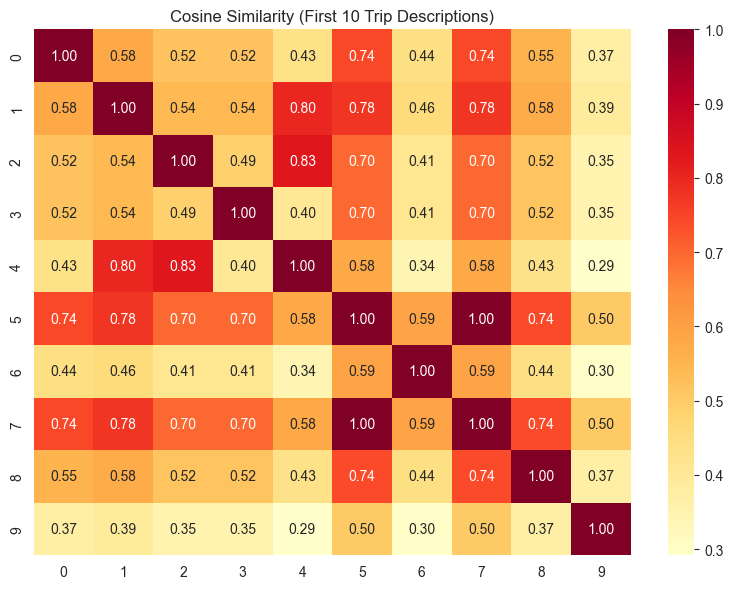

In [72]:
# Cosine similarity matrix (first 10 docs)
cos_sim = cosine_similarity(tfidf_matrix[:10])

plt.figure(figsize=(8, 6))
sns.heatmap(cos_sim, annot=True, fmt='.2f', cmap='YlOrRd', xticklabels=range(10), yticklabels=range(10))
plt.title('Cosine Similarity (First 10 Trip Descriptions)')
plt.tight_layout()
plt.show()

In [73]:
# Find most similar trip pairs
from itertools import combinations

sim_sample = cosine_similarity(tfidf_matrix[:200])
pairs = []
for i, j in combinations(range(200), 2):
    pairs.append((i, j, sim_sample[i, j]))

pairs.sort(key=lambda x: x[2], reverse=True)
print('Top 5 most similar trip description pairs:')
for i, j, sim in pairs[:5]:
    print(f'\nSimilarity: {sim:.4f}')
    print(f'  Trip {i}: {texts[i][:80]}...')
    print(f'  Trip {j}: {texts[j][:80]}...')

Top 5 most similar trip description pairs:

Similarity: 1.0000
  Trip 0: a standard rate taxi trip covering 1.8 miles with 1 passengers the fare was 16 d...
  Trip 24: a standard rate taxi trip covering 2.4 miles with 1 passengers the fare was 16 d...

Similarity: 1.0000
  Trip 0: a standard rate taxi trip covering 1.8 miles with 1 passengers the fare was 16 d...
  Trip 44: a standard rate taxi trip covering 2.4 miles with 4 passengers the fare was 16 d...

Similarity: 1.0000
  Trip 0: a standard rate taxi trip covering 1.8 miles with 1 passengers the fare was 16 d...
  Trip 59: a standard rate taxi trip covering 1.2 miles with 1 passengers the fare was 16 d...

Similarity: 1.0000
  Trip 0: a standard rate taxi trip covering 1.8 miles with 1 passengers the fare was 16 d...
  Trip 63: a standard rate taxi trip covering 1.7 miles with 1 passengers the fare was 16 d...

Similarity: 1.0000
  Trip 0: a standard rate taxi trip covering 1.8 miles with 1 passengers the fare was 16 d...
  Trip 

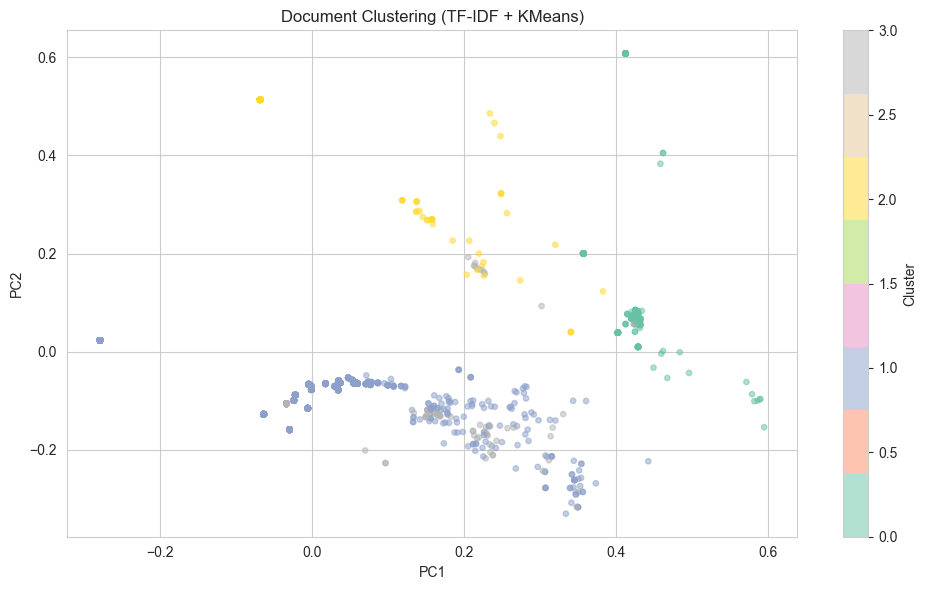

Top words per cluster:
  Cluster 0: ['cash', 'dollars', 'standard', 'tip', 'rate']
  Cluster 1: ['dollars', 'credit', 'card', 'standard', 'rate']
  Cluster 2: ['11', 'dollars', 'card', 'credit', 'standard']
  Cluster 3: ['10', 'dollars', 'card', 'credit', 'paid']


In [74]:
# Document clustering with TF-IDF + KMeans
from sklearn.cluster import KMeans as KM2

km_text = KM2(n_clusters=4, random_state=42, n_init=10)
text_clusters = km_text.fit_predict(tfidf_matrix)

# PCA visualization of document clusters
pca_text = PCA(n_components=2)
X_text_pca = pca_text.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_text_pca[:, 0], X_text_pca[:, 1], c=text_clusters, cmap='Set2', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title('Document Clustering (TF-IDF + KMeans)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# What words define each cluster?
print('Top words per cluster:')
order_centroids = km_text.cluster_centers_.argsort()[:, ::-1]
terms = tfidf.get_feature_names_out()
for i in range(4):
    top = [terms[ind] for ind in order_centroids[i, :5]]
    print(f'  Cluster {i}: {top}')

TF-IDF does a better job than raw BoW because it downweights words that appear everywhere. The cosine similarity heatmap shows trips with similar characteristics have higher scores. Document clustering groups trips by their text descriptions, and the top words per cluster match up with different trip profiles (short vs long, cash vs credit, airport vs city etc.).

---
## Summary

| Section | Topic | Key Takeaway |
|---------|-------|--------------|
| 1 | Data Loading | Millions of trips, 19 features, credit card is dominant payment |
| 2 | Cleaning & Viz | Small % of bad records removed, fares are right-skewed, evening rush peak |
| 3 | Descriptive Stats | All fare columns positively skewed, mean > median |
| 4 | Feature Prep | StandardScaler/MinMaxScaler applied, fare is top predictor of total |
| 5 | Classification | Random Forest gives best accuracy for high-tip prediction |
| 6 | Regression | Very high R2 for total_amount since it is sum of fare components |
| 7 | Tuning | GridSearchCV/RandomizedSearchCV find good RF hyperparameters |
| 8 | K-Means | 4 clusters separate short, medium, long and toll/airport trips |
| 9 | DBSCAN | Density approach catches outlier trips as noise |
| 10 | Generative AI | Bigram demo, prompt engineering concepts for data analysis |
| 11 | NLP | Tokenization, stopwords, stemming/lemmatization on trip text |
| 12 | Text Vectors | TF-IDF + cosine similarity finds similar trip patterns |